# Function 3 — Bayesian Optimization Campaign

This notebook documents the search for the input `(x1, x2, x3)` that **maximizes** an unknown
("black-box") 3D function. A Gaussian Process (GP) surrogate model is fit to the observed
data, and acquisition functions (Expected Improvement, Upper Confidence Bound) are used to
decide which point to query next.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import torch
import torch.nn as nn
import torch.optim as optim

## 2. Initial Data

In [2]:
X = np.load("function_3/data/initial_inputs.npy")
y = np.load("function_3/data/initial_outputs.npy")

Additional query rounds, appended as results came in:

In [3]:
X = np.append(X, [
    [0.151800, 0.439900, 0.990900],
    [0.000015, 0.999999, 0.999999],
    [0.651221, 0.411593, 0.540176],
    [0.626529, 0.211593, 0.424070],
    [0.851221, 0.211593, 0.740176],
    [0.851221, 0.611593, 0.504938],
    [0.959595, 0.811593, 0.399509],
    [0.900000, 0.811593, 0.495554],
    [0.851221, 0.611593, 0.504938],
    [0.851221, 0.611593, 0.504938],
    [0.851221, 0.611593, 0.504938],
    [0.905408, 0.711593, 0.452223],
    [0.751221, 0.511593, 0.404938],
    ], axis=0)

y = np.append(y, [
    -0.4108942135308994,
    -0.501755912728561,
    -0.033527902763252126,
    -0.03769506935981549,
    -0.1378589116427748,
    -0.013537192340862855,
    -0.02342642243954806,
    -0.03198731461075479,
    -0.02978517151201847,
    -0.004686647016489443,
    -0.027952721141016657,
    -0.012108937983944516,
    -0.006974822969405832,
    ], axis=0)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Best observed y so far: {max(y)}")

X shape: (28, 3), y shape: (28,)
Best observed y so far: -0.004686647016489443


## 3. Gaussian Process Surrogate Model

`Matern(nu=1.5)` is a good balance between smooth and rugged; a `WhiteKernel` term accounts
for observation noise. `n_restarts_optimizer` runs the hyperparameter tuning from multiple
starting points to find good length-scales.

In [4]:
kernel = 1.0 * Matern(length_scale=[1.0, 1.0, 1.0],
                      length_scale_bounds=(1e-2, 1e2),
                      nu=1.5) + WhiteKernel(noise_level=1e-5)

gp_model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    alpha=1e-1
)
gp_model.fit(X, y)

/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the spe

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP.If `None` is passed,the kernel `ConstantKernel() * RBF()` is used as default.Note thatthe kernel hyperparameters are optimized during fittingunless the bounds are marked as `""fixed""`or the argument `optimizer` is set to `None`.",1**2 * Matern...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",0.1
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,kernel__k1,"1**2 * Matern...1, 1], nu=1.5)"
,kernel__k2,WhiteKernel(noise_level=1e-05)
,kernel__k1__k1,1**2
,kernel__k1__k2,"Matern(length...1, 1], nu=1.5)"
,kernel__k1__k1__constant_value,1.0
,kernel__k1__k1__constant_value_bounds,"(1e-05, ...)"
,kernel__k1__k2__length_scale,"[1.0, 1.0, ...]"
,kernel__k1__k2__length_scale_bounds,"(0.01, ...)"


## 4. Acquisition Functions

### Expected Improvement (EI)
`xi` is the exploration parameter. The search is first run over the full unit cube, then
re-run starting from (and bounded around) the current best point.

In [5]:
def expected_improvement(x_new, model, current_best_y, xi=10):
    x_new = x_new.reshape(1, -1)
    mu, sigma = model.predict(x_new, return_std=True)
    sigma = sigma.flatten()[0]
    mu = mu.flatten()[0]

    if sigma <= 0:
        return 0.0

    improvement = mu - current_best_y - xi
    z = improvement / sigma
    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)

    return -ei

current_best_y = np.max(y)

x0 = X[np.argmax(y)]
res = minimize(expected_improvement, x0,
               bounds=[(0, 1), (0, 1), (0, 1)],
               args=(gp_model, current_best_y))

next_point = res.x
print(f"Suggested Next Iteration Point (EI, global bounds): {next_point}")

Suggested Next Iteration Point (EI, global bounds): [0.851221 0.611593 0.504938]


In [6]:
x_best = X[np.argmax(y)]
local_bounds = [(0, 1), (0, 1), (0, 1)]

res = minimize(expected_improvement, x_best,
               bounds=local_bounds,
               args=(gp_model, current_best_y))

next_point = res.x
print(f"Suggested Next Iteration Point (EI, local bounds around best): {next_point}")

Suggested Next Iteration Point (EI, local bounds around best): [0.851221 0.611593 0.504938]


Third iteration: UCB and EI over the full unit cube kept suggesting unexplored regions.
EI was kept but bounds were localized within the three known peaks, and the resulting
suggestions were more promising to actually run.

### Upper Confidence Bound (UCB)
`kappa` controls the exploration/exploitation trade-off; the search is restarted from many
random points to avoid getting stuck in a local optimum of the acquisition surface itself.

In [7]:
def upper_confidence_bound(x_test, kappa=10):
    mu, sigma = gp_model.predict(x_test.reshape(1, -1), return_std=True)
    ucb = mu + kappa * sigma
    return -ucb

def get_next_candidate(bounds, kappa=10, n_restarts=40):
    best_x = None
    min_ucb = float('inf')

    for starting_point in np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_restarts, 3)):
        res = minimize(
            fun=upper_confidence_bound,
            x0=starting_point,
            args=(kappa,),
            bounds=bounds,
            method='L-BFGS-B'
        )

        if res.fun < min_ucb:
            min_ucb = res.fun
            best_x = res.x

    return best_x

bounds = np.array([[0, 1], [0, 1], [0, 1]])
next_x = get_next_candidate(bounds, kappa=100)  # high kappa to find peaks
next_point = next_x
print(f"Suggested Next Iteration Point (UCB): {next_x}")

Suggested Next Iteration Point (UCB): [0. 0. 1.]


Probability of Improvement was also considered as an acquisition function but not used for this run's final candidate selection.

## 5. Supplementary Analysis — Neural Network Saliency

Existing samples are manually labeled "positive" (high-yield, indices
`[3, 4, 10, 13, 17, 18, 19, 20]`) or "negative", and a small neural network is trained on that
split as a sanity check on whether the acquisition function's suggested `next_point` also
looks promising from a classification standpoint. This is exploratory and not part of the
core GP/acquisition-function decision loop.

In [8]:
y_labels = np.zeros(len(X))
positive_indices = [3, 4, 10, 13, 17, 18, 19, 20]
y_labels[positive_indices] = 1

X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)
y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

nn_model_deep = nn.Sequential(
    nn.Linear(3, 10),
    nn.ReLU(),
    nn.Linear(10, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(nn_model_deep.parameters(), lr=0.01)
criterion = nn.BCELoss()

for _ in range(2000):
    optimizer.zero_grad()
    outputs = nn_model_deep(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

X_tensor.grad.zero_()
output = nn_model_deep(X_tensor)
output.backward(torch.ones_like(output))

deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")

Point | Deep Importance Score
 0    | 5.7310
 1    | 5.8030
 2    | 2.8226
 3    | 6.0071
 4    | 0.2368
 5    | 0.1284
 6    | 0.0000
 7    | 0.0014
 8    | 0.8761
 9    | 1.6612
10    | 6.4668
11    | 5.9134
12    | 0.1370
13    | 6.2774
14    | 0.0620
15    | 0.0000
16    | 0.0000
17    | 4.3679
18    | 1.3208
19    | 1.1876
20    | 3.6489
21    | 0.5308
22    | 0.2345
23    | 3.6489
24    | 3.6489
25    | 3.6489
26    | 1.5117
27    | 5.3236


In [9]:
nn_model_deep.eval()
sample_input = torch.tensor(np.array([next_point]), dtype=torch.float32)

with torch.no_grad():
    prediction_prob = nn_model_deep(sample_input)

print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")

Probability of being Positive (Class 1): 0.0000
Predicted Class: 0


## 6. Results Summary

Observed yield over the most recent iterations:

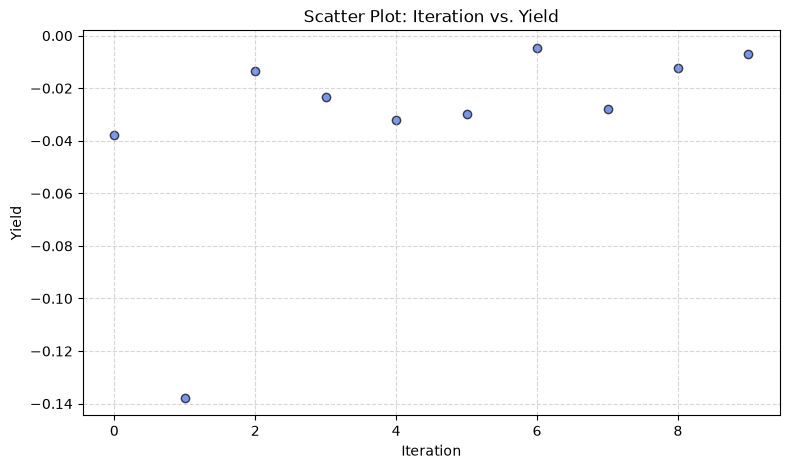

In [10]:
plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(0, 10)), y[-10:], color="royalblue", alpha=0.7, edgecolors="k"
)
plt.title("Scatter Plot: Iteration vs. Yield")
plt.xlabel("Iteration")
plt.ylabel("Yield")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()